In [1]:
# Cell 1: Imports and Setup
import random
import shutil
import subprocess
from pathlib import Path
from ultralytics import YOLO

In [4]:
# Cell 2: Define Paths
weights_path = Path("/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/mlruns/Stage 3/2347b4e3ce1845cc97003d5534fedf99/artifacts/weights/best.pt")
test_images_dir = Path("/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/processed/stage3/car_damages_panel/images/test")
output_project = Path("/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/reports/stage3_visuals")
output_name = "/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/results/stage3/test_predictions"

In [5]:
# Cell 3: Verify inputs
if not weights_path.exists():
    raise FileNotFoundError(f"Weights not found at: {weights_path}")
if not test_images_dir.exists():
    raise FileNotFoundError(f"Test images not found at: {test_images_dir}")
    
# Clean output directory if it exists
output_full_path = output_project / output_name
if output_full_path.exists():
    shutil.rmtree(output_full_path)

In [6]:
# Cell 4: Sample Images
image_extensions = {".jpg", ".jpeg", ".png"}
all_test_images = [p for p in test_images_dir.iterdir() if p.suffix.lower() in image_extensions]

sample_size = min(15, len(all_test_images))
sample_images = random.sample(all_test_images, sample_size)
print(f"🖼️  Selected {sample_size} random images from the test set.")

🖼️  Selected 15 random images from the test set.


In [7]:
# Cell 5: Load Model
print(f"⚙️  Loading weights from:\n    {weights_path}")
model = YOLO(str(weights_path))


⚙️  Loading weights from:
    /Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/mlruns/Stage 3/2347b4e3ce1845cc97003d5534fedf99/artifacts/weights/best.pt


In [8]:
# Cell 6: Run Inference on Apple Silicon (MPS)
print("🚀 Running predictions on M5 Mac (MPS)...")
results = model.predict(
    source=[str(img) for img in sample_images],
    save=True,
    project=str(output_project),
    name=output_name,
    exist_ok=True,
    conf=0.25,
    device="mps",        
    retina_masks=True,   
    line_width=2,
    show_labels=True,
    show_conf=True
)

🚀 Running predictions on M5 Mac (MPS)...

0: 640x640 1 Trunk, 1 Back-wheel, 1 Back-windshield, 2 Tail-lights, 1 Back-bumper, 1 Roof, 51.3ms
1: 640x640 1 Quarter-panel, 1 Front-wheel, 1 Back-window, 1 Trunk, 1 Front-door, 1 Rocker-panel, 1 Windshield, 1 Front-window, 1 Headlight, 1 Back-wheel, 1 Back-windshield, 1 Hood, 1 Fender, 1 Tail-light, 1 Front-bumper, 1 Back-bumper, 2 Mirrors, 1 Roof, 51.3ms
2: 640x640 2 Quarter-panels, 1 Front-wheel, 1 Back-window, 1 Front-door, 1 Rocker-panel, 1 Grille, 1 Windshield, 1 Front-window, 1 Back-door, 1 Back-wheel, 1 Hood, 1 Fender, 1 Front-bumper, 2 Mirrors, 1 Roof, 51.3ms
3: 640x640 1 Quarter-panel, 1 Front-wheel, 2 Back-windows, 1 Trunk, 1 Front-door, 1 Rocker-panel, 1 Front-window, 1 Back-door, 1 Back-wheel, 1 Back-windshield, 2 Fenders, 3 Tail-lights, 1 Back-bumper, 1 Mirror, 2 Roofs, 51.3ms
4: 640x640 1 Quarter-panel, 1 Front-wheel, 1 Back-window, 1 Front-door, 1 Rocker-panel, 1 Front-window, 1 Back-door, 1 Headlight, 1 Back-wheel, 2 Back-wind

In [9]:
# Cell 7: Display Results
print("\n" + "="*60)
print(f"✅ Visual predictions saved successfully!")
print(f"📂 Open this folder in Finder to inspect the boundaries:")
print(f"   {output_full_path.resolve()}")
print("="*60)

# Automatically open the folder in Finder on macOS
subprocess.run(["open", str(output_full_path.resolve())])


✅ Visual predictions saved successfully!
📂 Open this folder in Finder to inspect the boundaries:
   /Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/results/stage3/test_predictions


CompletedProcess(args=['open', '/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/results/stage3/test_predictions'], returncode=0)

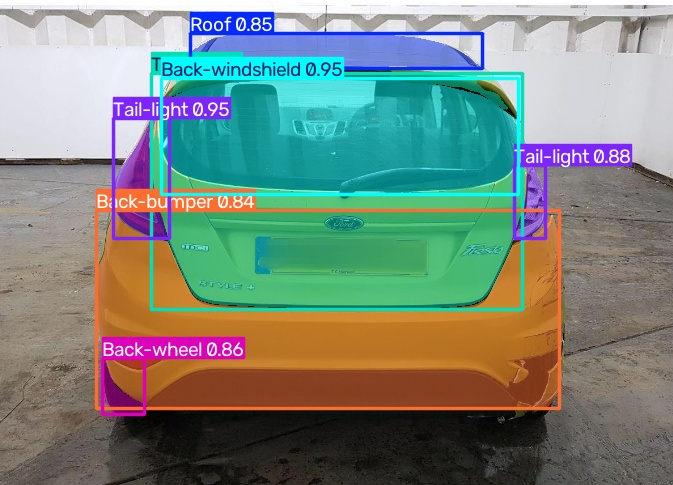

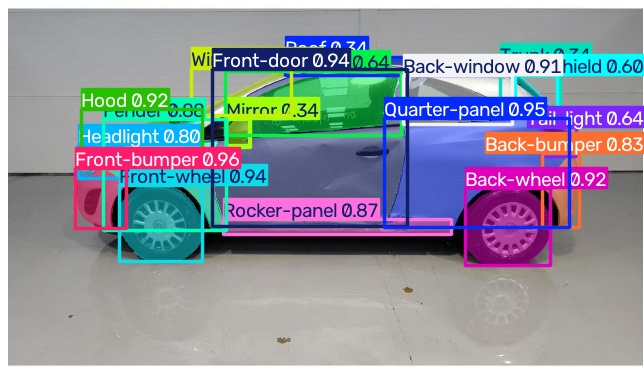

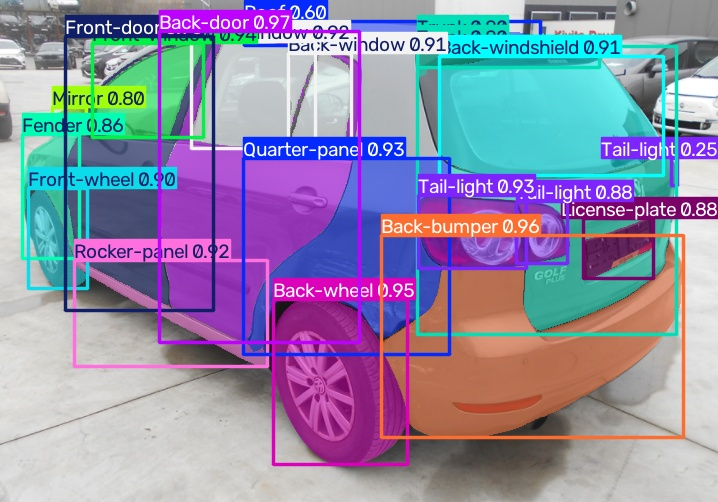

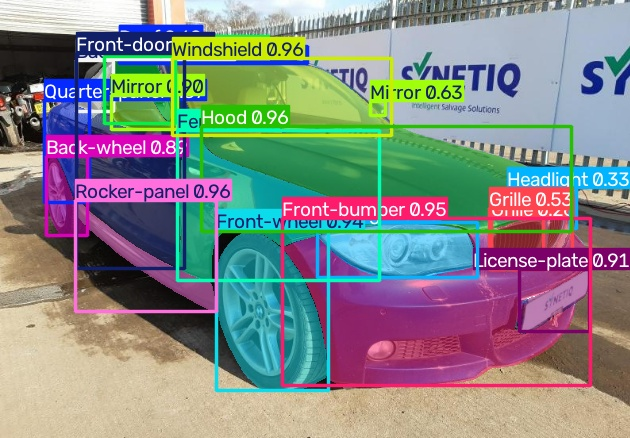

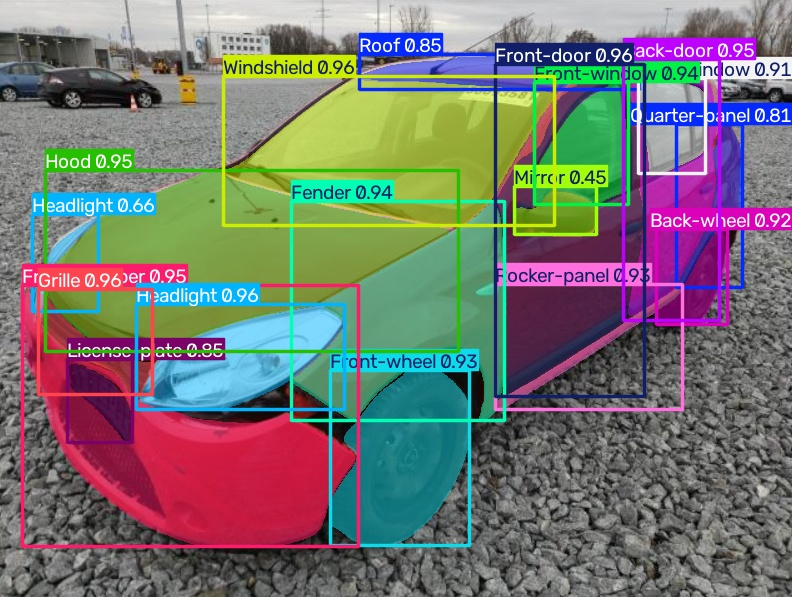

In [11]:
# Cell 8: Optional - Display some predictions inline (if running in Jupyter)
from IPython.display import Image, display
import glob

# Display first 3 prediction images
prediction_images = sorted(glob.glob(str(output_full_path / "*.jpg")))
for img_path in prediction_images[:5]:
    display(Image(filename=img_path, width=400))

In [14]:
# Single cell: Full evaluation
import json
from pathlib import Path
from ultralytics import YOLO
from IPython.display import display, Markdown

# Paths
DATA_YAML = Path("/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/processed/stage3/car_damages_panel/car_damages_panel.yaml")

# Load model
print("⚙️  Loading model...")
model = YOLO(str(weights_path))

# Run evaluation
print("🚀 Running test-set evaluation on MPS...")
metrics = model.val(
    data=str(DATA_YAML),
    split="test",
    device="mps",
    imgsz=640,
    batch=8,
    plots=True,
)

# Display results
print("\n" + "=" * 70)
print("STAGE 3 TEST-SET RESULTS (held-out 100 images)")
print("=" * 70)
print(f"Box  -> P: {metrics.box.mp:.3f}  R: {metrics.box.mr:.3f}  mAP50: {metrics.box.map50:.3f}  mAP50-95: {metrics.box.map:.3f}")
print(f"Mask -> P: {metrics.seg.mp:.3f}  R: {metrics.seg.mr:.3f}  mAP50: {metrics.seg.map50:.3f}  mAP50-95: {metrics.seg.map:.3f}")

names = model.names
print("\nPer-class Mask mAP50:")
for i, ap50 in enumerate(metrics.seg.ap50):
    print(f"  {names[i]:>16}: {ap50:.3f}")

# Save metrics
out = {
    "box": {"precision": metrics.box.mp, "recall": metrics.box.mr,
            "mAP50": metrics.box.map50, "mAP50-95": metrics.box.map},
    "mask": {"precision": metrics.seg.mp, "recall": metrics.seg.mr,
             "mAP50": metrics.seg.map50, "mAP50-95": metrics.seg.map},
    "per_class_mask_mAP50": {names[i]: float(metrics.seg.ap50[i]) for i in range(len(names))},
}

out_path = Path("reports/stage3_eval/test_set_metrics.json")
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w") as f:
    json.dump(out, f, indent=2)
    
print(f"\n✅ Saved metrics JSON to: {out_path.resolve()}")

⚙️  Loading model...
🚀 Running test-set evaluation on MPS...
Ultralytics 8.4.91 🚀 Python-3.10.20 torch-2.13.0 MPS (Apple M1 Pro)
YOLO26m-seg summary (fused): 149 layers, 23,523,659 parameters, 0 gradients, 121.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.6 ms, read: 1191.4±566.0 MB/s, size: 699.0 KB)
val: Scanning /Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/processed/stage3/car_damages_panel/labels/test... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 1.3Kit/s 0.1s
val: New cache created: /Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/processed/stage3/car_damages_panel/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.1it/s 11.6s0.7s
                   all        100       1621      0.888      0.807      0.871      0.673      0.885      0.824      0.879      0.626
  